# 9 - accDM daughter: slaving-fidelity test (Phase-2 decision input)

Phase 1 measured how *stiff* the daughter is at fluid switch-on. It never measured how well the daughter can actually be **slaved to the parent**, which is what decides whether the Phase-2 `acctca` regime (slave the daughter to the dcdm parent from production, collapsing its ~`(l_max+1) x q_size` Boltzmann hierarchy to a few algebraic relations) can beat the exact hierarchy on wall-time.

This notebook extracts, from a single **exact** run, the daughter bulk moments (`delta_acc, theta_acc, sigma_acc`) and the parent (`delta_dcdm, theta_dcdm`) at several k, and computes the 0th-order slaving residuals:

- density:  `|delta_acc - delta_dcdm| / |delta_acc|`
- velocity: `theta_acc / theta_dcdm`  (the empirical slaving coefficient; the spec assumes 3/4)
- shear:    `|sigma_acc| / |delta_acc|`  (the free-streaming term 0th-order slaving sets to 0)

**What the result means.** The fraction of the post-production a-range where these stay small is an optimistic upper bound on the span an `acctca` slave-from-production could cover - i.e. the speedup ceiling beyond the fluid's measured ~1.8x. The *dominant* residual says whether 0th-order slaving suffices (delta-tracking), needs a first-order velocity slip (theta), or fundamentally does not fit (sigma).

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

plt.rcParams.update({'mathtext.fontset': 'stix', 'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'legend.fontsize': 9, 'lines.linewidth': 1.5, 'figure.dpi': 300})
qual = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3']

def find_key(d, *cands):
    for c in cands:
        if c in d:
            return c
    for key in d:
        for c in cands:
            if c in key:
                return key
    raise KeyError('none of {} in keys like {}'.format(cands, list(d)[:20]))

DEN_FLOOR = 1e-30
def safe_ratio(num, den):
    d = np.where(np.abs(den) > DEN_FLOOR, den, np.nan)
    return num / d

## Parameters (same boosted accDM model as notebook 6, kappa = 4.0)

In [2]:
omega_b = 0.022383; omega_cdm0 = 0.12011
A_s = 2.1005829616811546e-9; n_s = 0.96605; tau_reio = 0.0543; H0 = 67.32
A_T = 0.13; MASS = 1e16; F_ACC = 0.1; ETA = 0.1; A_REC = 1.0 / (1.0 + 1090.0)
KAPPA = 4.0
K_OUT = [0.01, 0.05, 0.2, 1.0]   # 1/Mpc; sub-horizon focus (super-horizon is gauge-contaminated, see notes)

def exact_params(kappa, k_out):
    ocdm = omega_cdm0 * (1 + F_ACC*(1 - A_REC**kappa)/(1 + (A_REC/A_T)**kappa))**(-1)
    p = {'omega_b': omega_b, 'omega_cdm': ocdm, 'H0': H0,
         'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}
    p.update({'output': 'dTk, vTk', 'gauge': 'synchronous',
              'get_perturbations_in_current_gauge': 'yes',
              'k_output_values': ', '.join('{:.6e}'.format(k) for k in k_out),
              'evolver': 0, 'background_Nloga': 5000,
              'vary_Gamma_acc': 'yes', 'kappa_acc': kappa, 'a_t_acc': A_T,
              'f_acc': F_ACC, 'eta_acc': ETA,
              'm_acc_in_GeV': MASS, 'm_cdm_in_GeV': MASS,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(MASS*1e9),
              'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 4',
              'ncdm_N_momentum_bins': '15, 1001', 'N_ur': 0.00441,
              'ncdm_fluid_approximation': 3})
    return p

In [3]:
M = Class(); M.set(exact_params(KAPPA, K_OUT))
t0 = time.perf_counter()
M.compute()
print('exact run: {:.1f}s'.format(time.perf_counter() - t0))

pert = M.get_perturbations()['scalar']
bg = M.get_background()
print('captured {} k-modes'.format(len(pert)))
print('available perturbation keys:')
print([key for key in pert[0].keys()])

exact run: 37.9s
captured 4 k-modes
available perturbation keys:
['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'eta_prime', 'h_prime', 'phi_prime', 'rho_plus_p_theta', 'delta_rho_tot', 'eta', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm', 'delta_ncdm[0]', 'theta_ncdm[0]', 'shear_ncdm[0]', 'cs2_ncdm[0]', 'w_p[0]', 'w_theta[0]', 'w_sigma[0]', 'k_fss_acc[0]', 'delta_ncdm[1]', 'theta_ncdm[1]', 'shear_ncdm[1]', 'cs2_ncdm[1]', 'w_p[1]', 'w_theta[1]', 'w_sigma[1]', 'k_fss_acc[1]', 'w_trial_1', 'w_trial_2', 'delta_dcdm', 'theta_dcdm']


## Daughter coldness and slaving residuals

First the background equation of state `w = p/rho` of the daughter (how cold it is - cold favours slaving), then the per-k 0th-order slaving residuals.

In [4]:
# daughter equation of state from the background (coldness proxy)
try:
    bg_a = 1.0 / (1.0 + bg[find_key(bg, 'z')])
    rho_d = bg[find_key(bg, '(.)rho_ncdm[1]', 'rho_ncdm[1]')]
    p_d = bg[find_key(bg, '(.)p_ncdm[1]', 'p_ncdm[1]')]
    w_d = p_d / rho_d
    order = np.argsort(bg_a); bg_a = bg_a[order]; w_d = w_d[order]
    w_AT = float(np.interp(A_T, bg_a, w_d)); w_1 = float(np.interp(1.0, bg_a, w_d))
    print('daughter w = p/rho:  at a=A_T={:.3g} -> {:.3e}   at a=1 -> {:.3e}'.format(A_T, w_AT, w_1))
except Exception as e:
    bg_a = w_d = None
    print('background w unavailable ({}); skipping coldness curve'.format(e))

# per-k slaving residuals
data = []
for i, k in enumerate(K_OUT):
    P = pert[i]
    ak = P[find_key(P, 'a')]
    da = P[find_key(P, 'delta_ncdm[1]')]
    ta = P[find_key(P, 'theta_ncdm[1]')]
    sa = P[find_key(P, 'shear_ncdm[1]')]
    dd = P[find_key(P, 'delta_dcdm')]
    td = P[find_key(P, 'theta_dcdm')]
    data.append(dict(k=k, a=ak, da=da, ta=ta, sa=sa, dd=dd, td=td,
        R_delta=np.abs(safe_ratio(da - dd, da)),
        R_theta075=np.abs(safe_ratio(ta - 0.75*td, ta)),
        ratio_theta=safe_ratio(ta, td),
        S_over_D=np.abs(safe_ratio(sa, da))))
print('extracted residuals for k =', K_OUT)

daughter w = p/rho:  at a=A_T=0.13 -> 3.550e-02   at a=1 -> 1.800e-03
extracted residuals for k = [0.01, 0.05, 0.2, 1.0]


/tmp/ipykernel_78311/2913512590.py:6: RuntimeWarning: invalid value encountered in divide
  w_d = p_d / rho_d


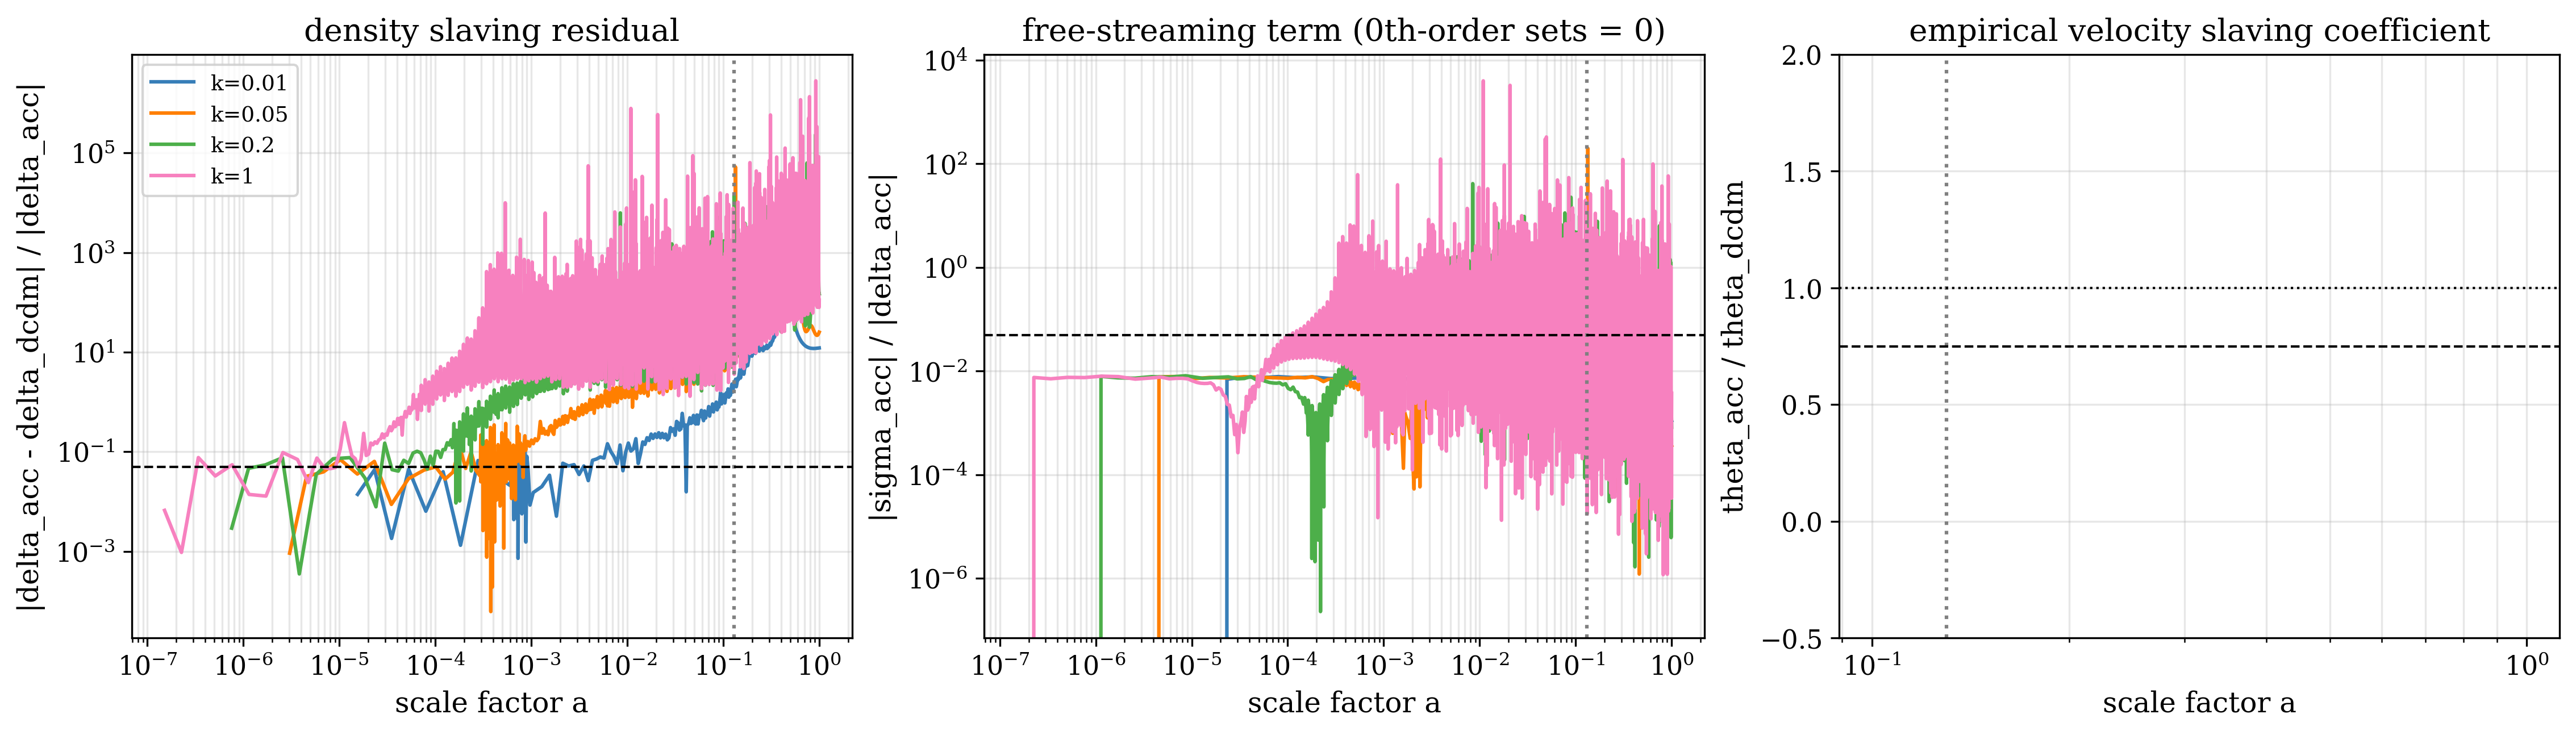

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
for d, c in zip(data, qual):
    ax[0].loglog(d['a'], d['R_delta'], color=c, label='k={:.2g}'.format(d['k']))
    ax[1].loglog(d['a'], d['S_over_D'], color=c)
    ax[2].semilogx(d['a'], d['ratio_theta'], color=c)
for a_ in ax:
    a_.axvline(A_T, color='0.5', ls=':')
    a_.set_xlabel('scale factor a')
    a_.grid(True, which='both', alpha=0.3)
ax[0].axhline(0.05, color='k', ls='--', lw=1)
ax[0].set_ylabel('|delta_acc - delta_dcdm| / |delta_acc|')
ax[0].set_title('density slaving residual')
ax[0].legend(loc='best')
ax[1].axhline(0.05, color='k', ls='--', lw=1)
ax[1].set_ylabel('|sigma_acc| / |delta_acc|')
ax[1].set_title('free-streaming term (0th-order sets = 0)')
ax[2].axhline(0.75, color='k', ls='--', lw=1)
ax[2].axhline(1.0, color='k', ls=':', lw=1)
ax[2].set_ylabel('theta_acc / theta_dcdm')
ax[2].set_title('empirical velocity slaving coefficient')
ax[2].set_ylim(-0.5, 2.0)
plt.show()

In [6]:
TOL = 0.05
print('Post-production slaveable fraction  (a in [A_T={:.3g}, 1], log-a weighted, tol={:.0%})'.format(A_T, TOL))
print('{:>8} {:>13} {:>13} {:>13} {:>14}'.format('k', 'frac(delta)', 'frac(sigma)', 'frac(both)', 'worst-moment'))
for d in data:
    m = d['a'] >= A_T
    la = np.log(d['a'][m])
    if la.size < 2:
        print('{:>8.2g}  insufficient post-production samples'.format(d['k'])); continue
    w = np.gradient(la)
    def frac(mask):
        mm = mask[m]
        return float(np.sum(w[mm]) / np.sum(w))
    fd = frac(d['R_delta'] < TOL)
    fs = frac(d['S_over_D'] < TOL)
    fb = frac((d['R_delta'] < TOL) & (d['S_over_D'] < TOL))
    med = {'delta': np.nanmedian(d['R_delta'][m]),
           'sigma': np.nanmedian(d['S_over_D'][m]),
           'theta-slip': np.nanmedian(d['R_theta075'][m])}
    worst = max(med, key=med.get)   # the moment with the LARGEST median residual = the binding obstacle
    print('{:>8.2g} {:>13.1%} {:>13.1%} {:>13.1%} {:>14}'.format(d['k'], fd, fs, fb, worst))
print()
print('Reading the table (worst-moment = the moment with the LARGEST median residual = the binding obstacle):')
print('  worst=delta -> density is the obstacle: delta_acc does not equal delta_dcdm. See next cell for whether it is a fittable ratio.')
print('  worst=theta-slip -> velocity is the obstacle: need 0th + first-order velocity slip (1/Lambda).')
print('  worst=sigma -> free-streaming is the obstacle: slaved (shear-free) shape does not fit; capped near the fluid 1.8x.')

Post-production slaveable fraction  (a in [A_T=0.13, 1], log-a weighted, tol=5%)
       k   frac(delta)   frac(sigma)    frac(both)   worst-moment
    0.01          0.0%         83.0%          0.0%          delta
    0.05          0.0%         83.1%          0.0%          delta
     0.2          0.0%         81.1%          0.0%          delta
       1          0.0%         79.0%          0.0%          delta

Reading the table (worst-moment = the moment with the LARGEST median residual = the binding obstacle):
  worst=delta -> density is the obstacle: delta_acc does not equal delta_dcdm. See next cell for whether it is a fittable ratio.
  worst=theta-slip -> velocity is the obstacle: need 0th + first-order velocity slip (1/Lambda).
  worst=sigma -> free-streaming is the obstacle: slaved (shear-free) shape does not fit; capped near the fluid 1.8x.


In [7]:
# Refined diagnostic: is the density mismatch a FITTABLE relation, and how tight is the tolerance?
# (slv08 showed delta_acc != delta_dcdm at 5%, but sigma is small. The question now: does
#  delta_acc/delta_dcdm sit at a stable ratio -> a coefficient slaving delta_acc = alpha*delta_dcdm
#  would recover it; and at what tolerance does the slaveable fraction become large.)
print('Per-k, post-production (a>=A_T): delta/theta ratio stats + tolerance sweep')
for d in data:
    m = d['a'] >= A_T
    dd_safe = np.where(np.abs(d['dd'][m]) > DEN_FLOOR, d['dd'][m], np.nan)
    rd = d['da'][m] / dd_safe                 # delta_acc / delta_dcdm
    rt = d['ratio_theta'][m]                   # theta_acc / theta_dcdm
    la = np.log(d['a'][m]); w = np.gradient(la)
    def frac(mask):
        return float(np.sum(w[mask]) / np.sum(w))
    sweep = [(tol, frac((d['R_delta'][m] < tol) & (d['S_over_D'][m] < tol))) for tol in (0.05, 0.1, 0.2, 0.3, 0.5)]
    print('k={:.2g}:'.format(d['k']))
    print('   delta_acc/delta_dcdm  median={:.2f}  IQR=[{:.2f}, {:.2f}]'.format(np.nanmedian(rd), np.nanpercentile(rd, 25), np.nanpercentile(rd, 75)))
    print('   theta_acc/theta_dcdm  median={:.2f}  IQR=[{:.2f}, {:.2f}]'.format(np.nanmedian(rt), np.nanpercentile(rt, 25), np.nanpercentile(rt, 75)))
    print('   frac(both<tol):  ' + '  '.join('{:.0%}:{:.0%}'.format(t, f) for t, f in sweep))
print()
print('Stable delta_acc/delta_dcdm median + tight IQR -> coefficient slaving delta_acc = alpha*delta_dcdm works (like the theta coeff).')
print('Wide IQR / drifting median -> daughter density is not a slaved function of the parent; acctca cannot beat the fluid.')

Per-k, post-production (a>=A_T): delta/theta ratio stats + tolerance sweep
k=0.01:
   delta_acc/delta_dcdm  median=0.07  IQR=[0.03, 0.08]
   theta_acc/theta_dcdm  median=nan  IQR=[nan, nan]
   frac(both<tol):  5%:0%  10%:0%  20%:0%  30%:0%  50%:0%
k=0.05:
   delta_acc/delta_dcdm  median=0.00  IQR=[-0.02, 0.03]
   theta_acc/theta_dcdm  median=nan  IQR=[nan, nan]
   frac(both<tol):  5%:0%  10%:0%  20%:0%  30%:0%  50%:0%
k=0.2:
   delta_acc/delta_dcdm  median=0.00  IQR=[-0.01, 0.01]
   theta_acc/theta_dcdm  median=nan  IQR=[nan, nan]
   frac(both<tol):  5%:0%  10%:0%  20%:0%  30%:0%  50%:0%
k=1:
   delta_acc/delta_dcdm  median=-0.00  IQR=[-0.01, 0.01]
   theta_acc/theta_dcdm  median=nan  IQR=[nan, nan]
   frac(both<tol):  5%:0%  10%:0%  20%:0%  30%:0%  50%:0%

Stable delta_acc/delta_dcdm median + tight IQR -> coefficient slaving delta_acc = alpha*delta_dcdm works (like the theta coeff).
Wide IQR / drifting median -> daughter density is not a slaved function of the parent; acctca cannot be

/tmp/ipykernel_78311/3169306181.py:17: RuntimeWarning: All-NaN slice encountered
  print('   theta_acc/theta_dcdm  median={:.2f}  IQR=[{:.2f}, {:.2f}]'.format(np.nanmedian(rt), np.nanpercentile(rt, 25), np.nanpercentile(rt, 75)))
/home/agomulka/.pyenv/versions/accDM/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


## Caveats (read before trusting the numbers)

- **Super-horizon is gauge-contaminated.** The accDM daughter is gauge-invariant only sub-horizon; the daughter-tracking IC breaks gauge-invariance at large scales. Trust k that are sub-horizon over the post-production window (the smallest k here, 0.01, is borderline) and weight the verdict toward k >= 0.05.
- **Early residuals are artificially zero.** Before each momentum mode is born (a <= aq) the code already pins the daughter to the parent (`perturbations.c:10279`). That makes `R_delta -> 0` pre-production by construction, so only the post-production window (a >= A_T) is informative - hence the cut in the table.
- **Synchronous gauge theta.** `theta_dcdm` is the parent velocity in synchronous gauge; the empirical `theta_acc/theta_dcdm` panel shows the *actual* slaving coefficient, which need not be the spec's 3/4. If the ratio is noisy or blows up, theta is small and the velocity slaving is near-trivial.
- **frac(both) is an a-range fraction, not a guaranteed wall-time speedup.** Cost is not uniform in a, and the per-q birth staggering means part of the early hierarchy is unavoidable. Treat it as the ceiling, then confirm with a real acctca prototype before committing.
- No rebuild needed: this runs against the existing built classy. If `delta_ncdm[1]` is missing from the perturbation keys, add `dTk, vTk` to `output` (already set here).